#                        ***Customer Purchase Behavior Analysis & Prediction***

### 🔹 Environment Setup through required libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### 🔹 Step 1: Data Cleansing & Preprocessing
#### Before performing any cleaning operations, it is essential to understand the dataset structure, column types, and data quality issues.

#### The objective of **Step 1** is to:

* Clean and standardize the dataset
* Handle missing and inconsistent data
* Remove duplicate records
* Detect and treat outliers
* Engineer meaningful business-driven features

After completing this step, the dataset becomes **ML-ready** and suitable for:

* Customer Segmentation (Clustering)
* Customer Lifetime Value (CLV) Prediction
* Churn Prediction


In [9]:
# Dataset Loading
df = pd.read_excel('Amazon_Customer_Purchase_Data.xlsx')
df.head(3)

,Customer_ID,Customer_Name,Age,Gender,Location,Product_Category,Product_ID,Purchase_Date,Purchase_Amount,Payment_Method,Rating,Feedback_Comments,Customer_Lifetime_Value,Loyalty_Score,Discount_Applied,Return_Status,Customer_Segment,Preferred_Shopping_Channel
0,17270,John,56.0,Other,New York,Books,674,2020-01-01 00:00:00,491.643012,Cash,NaN,NaN,3673.712747,60,No,No,Regular,In-store
1,10860,Eve,33.0,Other,Houston,Home Appliances,393,2020-01-01 01:00:00,144.326722,Cash,5.0,Good,2103.060388,29,Yes,Yes,New,In-store
2,15390,John,50.0,Female,Houston,Clothing,995,2020-01-01 02:00:00,109.301892,Bank Transfer,NaN,NaN,899.115059,92,No,No,VIP,Online


In [10]:
# Dataset dimensions
df.shape

(2000, 18)

In [4]:
# Data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Customer_ID                 2000 non-null   int64         
 1   Customer_Name               1900 non-null   object        
 2   Age                         1900 non-null   float64       
 3   Gender                      2000 non-null   object        
 4   Location                    2000 non-null   object        
 5   Product_Category            2000 non-null   object        
 6   Product_ID                  2000 non-null   int64         
 7   Purchase_Date               2000 non-null   datetime64[ns]
 8   Purchase_Amount             1800 non-null   float64       
 9   Payment_Method              2000 non-null   object        
 10  Rating                      1860 non-null   float64       
 11  Feedback_Comments           1099 non-null   object      

In [5]:
# Statistical summary
df.describe(include='all')

,Customer_ID,Customer_Name,Age,Gender,Location,Product_Category,Product_ID,Purchase_Date,Purchase_Amount,Payment_Method,Rating,Feedback_Comments,Customer_Lifetime_Value,Loyalty_Score,Discount_Applied,Return_Status,Customer_Segment,Preferred_Shopping_Channel
count,2000.000000,1900,1900.000000,2000,2000,2000,2000.000000,2000,1800.000000,2000,1860.000000,1099,1800.000000,2000.00000,2000,2000,2000,2000
unique,NaN,5,NaN,3,5,5,NaN,NaN,NaN,4,NaN,4,NaN,NaN,2,2,3,3
top,NaN,Eve,NaN,Female,New York,Toys,NaN,NaN,NaN,Credit Card,NaN,Good,NaN,NaN,No,No,Regular,Online
freq,NaN,398,NaN,687,434,437,NaN,NaN,NaN,509,NaN,290,NaN,NaN,1397,1588,824,999
mean,15022.171500,NaN,43.696316,NaN,NaN,NaN,546.669000,2020-02-11 15:29:59.999999744,257.954370,NaN,2.978495,NaN,2566.724026,51.45700,NaN,NaN,NaN,NaN
min,10001.000000,NaN,18.000000,NaN,NaN,NaN,100.000000,2020-01-01 00:00:00,10.077295,NaN,1.000000,NaN,56.153142,1.00000,NaN,NaN,NaN,NaN
25%,12585.750000,NaN,31.000000,NaN,NaN,NaN,320.750000,2020-01-21 19:45:00,134.525844,NaN,2.000000,NaN,1218.808126,26.00000,NaN,NaN,NaN,NaN
50%,15104.500000,NaN,43.000000,NaN,NaN,NaN,551.000000,2020-02-11 15:30:00,257.545509,NaN,3.000000,NaN,2305.364380,52.00000,NaN,NaN,NaN,NaN
75%,17408.250000,NaN,57.000000,NaN,NaN,NaN,763.000000,2020-03-03 11:15:00,383.819725,NaN,4.000000,NaN,3651.162484,76.00000,NaN,NaN,NaN,NaN
max,19998.000000,NaN,69.000000,NaN,NaN,NaN,998.000000,2020-03-24 07:00:00,499.839871,NaN,5.000000,NaN,7204.408434,100.00000,NaN,NaN,NaN,NaN


#### 🔹 Step 1.1: Handling Missing Values

Business Rationale:
In missing values can bias ML models or cause them to fail. Appropriate imputation ensures data completeness while preserving statistical properties.

Strategy Used:
* Numerical Columns → Median Imputation (robust to outliers)
* Categorical Columns → Mode Imputation
  
Columns addressed:
* Age
* Handle missing and inconsistent data
* Purchase Amount
* Rating
* Customer Lifetime Value (CLV)
* Payment Method


##### 🔹 Identify missing values in Age, Purchase Amount, Rating, and Customer Lifetime Value¶

In [6]:
df.isnull().sum()

Customer_ID                     0
Customer_Name                 100
Age                           100
Gender                          0
Location                        0
Product_Category                0
Product_ID                      0
Purchase_Date                   0
Purchase_Amount               200
Payment_Method                  0
Rating                        140
Feedback_Comments             901
Customer_Lifetime_Value       200
Loyalty_Score                   0
Discount_Applied                0
Return_Status                   0
Customer_Segment                0
Preferred_Shopping_Channel      0
dtype: int64

##### 🔹 Apply mean/median imputation for numerical fields.

In [7]:
# Median imputation for numerical columns
num_cols = ['Age', 'Purchase_Amount', 'Rating', 'Customer_Lifetime_Value']
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_130780\2274873822.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


##### 🔹 Apply mode imputation for categorical fields like Payment Method.

In [8]:
# Mode imputation for categorical column
df['Payment_Method'].fillna(df['Payment_Method'].mode()[0], inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_130780\1329588601.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Payment_Method'].fillna(df['Payment_Method'].mode()[0], inplace=True)


In [9]:
# Verify missing values are handled
df.isnull().sum()

Customer_ID                     0
Customer_Name                 100
Age                             0
Gender                          0
Location                        0
Product_Category                0
Product_ID                      0
Purchase_Date                   0
Purchase_Amount                 0
Payment_Method                  0
Rating                          0
Feedback_Comments             901
Customer_Lifetime_Value         0
Loyalty_Score                   0
Discount_Applied                0
Return_Status                   0
Customer_Segment                0
Preferred_Shopping_Channel      0
dtype: int64

*** Note : Missing values were identified in Age, Purchase Amount, Rating, and Customer Lifetime Value. Median imputation was applied to these numerical fields. Post-imputation validation confirmed that all missing values in the specified columns were successfully handled.

#### 🔹 Step 1.2: Removing Duplicates
Duplicates transactions can inflate revenue, CLV and loyalty metrics, leading to incorrect business insights. Duplicates are identified using:
- Customer_ID
- Purchase_Date

##### 🔹 Remove duplicate entries based on Customer_ID and Purchase_Date.

In [11]:
# Identify duplicate records based on Customer_ID and Purchase_Date
duplicate_count = df. duplicated(subset=['Customer_ID', 'Purchase_Date']).sum()
duplicate_count

0

#### Note: Duplicate records were checked using Customer_ID and Purchase_Date. No duplicate entries were found in the dataset; therefore, no records were removed at this stage.

#### 🔹 Step 1.3: Data Formatting & Type Correction

##### 🔹 Convert Purchase_Date to datetime format.

In [26]:
# Inspect Current Data Types
df.dtypes

Customer_ID                            int64
Customer_Name                         object
Age                                  float64
Gender                              category
Location                            category
Product_Category                    category
Product_ID                             int64
Purchase_Date                 datetime64[ns]
Purchase_Amount                      float64
Payment_Method                      category
Rating                               float64
Feedback_Comments                     object
Customer_Lifetime_Value              float64
Loyalty_Score                          int64
Discount_Applied                    category
Return_Status                       category
Customer_Segment                    category
Preferred_Shopping_Channel          category
dtype: object

#### Observation: The Purchase_Date column is already in datetime64[ns] format. Therefore, no additional conversion was required.

##### 🔹  Standardize categorical values (e.g., Gender: Male, Female, Other).

In [19]:
# Standardize Gender values
df['Gender'] = df['Gender'].str.strip().str.capitalize()

df['Gender'] = df['Gender'].replace({
    'M': 'Male',
    'F': 'Female'
})


In [20]:
df['Gender'].unique()

array(['Other', 'Female', 'Male'], dtype=object)

#### Note : Categorical variables were reviewed for consistency. All categorical columns, including Gender, were already standardized and therefore did not require transformation.

##### 🔹  Ensure consistent data types (integers for numeric fields, categorical encoding for nonnumeric).

In [22]:
# Ensure categorical columns are treated as categorical

categorical_cols = [
    'Gender',
    'Location',
    'Product_Category',
    'Payment_Method',
    'Discount_Applied',
    'Return_Status',
    'Customer_Segment',
    'Preferred_Shopping_Channel'
]

df[categorical_cols] = df[categorical_cols].astype('category')

In [21]:
df.dtypes

Customer_ID                            int64
Customer_Name                         object
Age                                  float64
Gender                              category
Location                            category
Product_Category                    category
Product_ID                             int64
Purchase_Date                 datetime64[ns]
Purchase_Amount                      float64
Payment_Method                      category
Rating                               float64
Feedback_Comments                     object
Customer_Lifetime_Value              float64
Loyalty_Score                          int64
Discount_Applied                    category
Return_Status                       category
Customer_Segment                    category
Preferred_Shopping_Channel          category
dtype: object

In [16]:
df[categorical_cols].dtypes

Gender                        category
Location                      category
Product_Category              category
Payment_Method                category
Discount_Applied              category
Return_Status                 category
Customer_Segment              category
Preferred_Shopping_Channel    category
dtype: object

In [19]:
df.select_dtypes(include=['int64', 'float64']).columns

Index(['Customer_ID', 'Age', 'Product_ID', 'Purchase_Amount', 'Rating',
       'Customer_Lifetime_Value', 'Loyalty_Score'],
      dtype='object')

#### Note : Data types were reviewed to ensure alignment with business meaning. Numeric variables such as purchase amounts, ratings, and lifetime value were retained as floating-point values, while identifier and count-based fields were stored as integers. Non-numeric features relevant for machine learning were explicitly cast as categorical data types. No additional data type corrections were required.

#### 🔹 Step 1.4: Handling Outliers

##### 🔹  Identify outliers in Purchase Amount & CLV using boxplots & z-score analysis.

In [ ]:
## Visual inspection using boxplots

In [24]:
outlier_cols = ['Purchase_Amount', 'Customer_Lifetime_Value']

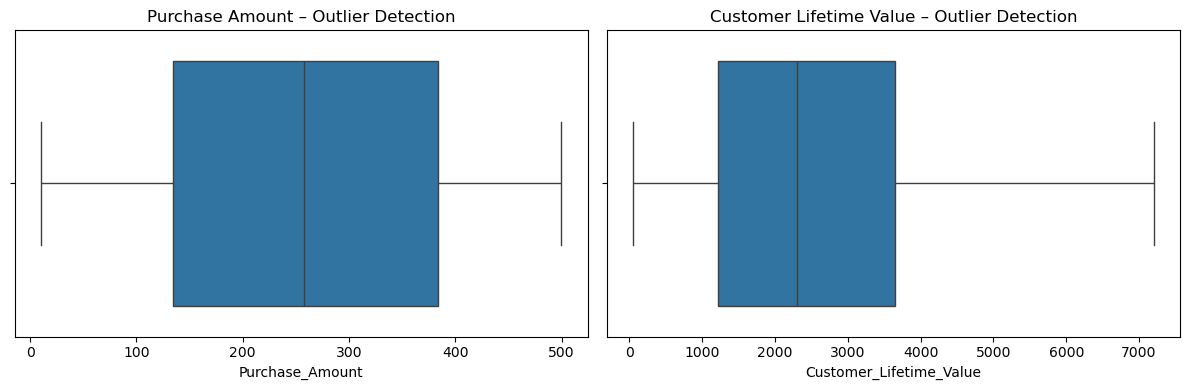

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.boxplot(x=df['Purchase_Amount'])
plt.title('Purchase Amount – Outlier Detection')

plt.subplot(1,2,2)
sns.boxplot(x=df['Customer_Lifetime_Value'])
plt.title('Customer Lifetime Value – Outlier Detection')

plt.tight_layout()
plt.show()


##### Note: The Purchase Amount distribution does not exhibit extreme outliers based on boxplot analysis.

##### Note: The Customer Lifetime Value distribution shows higher variability with a right-skewed distribution, but no visually isolated extreme outliers.

#### *** ***Boxplots for Purchase Amount and Customer Lifetime Value were examined to identify potential outliers. The analysis did not reveal any extreme outliers beyond the whiskers. High values observed in both variables appear to represent valid customer behavior rather than anomalies.*** ***

In [28]:
## Select columns for Z-score analysis
outlier_cols = ['Purchase_Amount', 'Customer_Lifetime_Value']

In [29]:
## Compute Z-scores
from scipy.stats import zscore

z_scores = df[outlier_cols].apply(zscore)

In [30]:
## Identify potential outliers (|Z| > 3)
# Count values with absolute Z-score greater than 3
(z_scores.abs() > 3).sum()

Purchase_Amount            0
Customer_Lifetime_Value    0
dtype: int64

#### *** ***Z-score analysis was applied to Purchase Amount and Customer Lifetime Value to statistically identify extreme outliers. Using a threshold of |Z| > 3, no extreme outliers were detected. This confirms the boxplot findings and indicates that high values represent valid customer behavior rather than anomalies.*** ***

#### 🔹 Step 1.5: Feature Engineering (Adding New Columns)

#### *** ***The dataset already contains several engineered features required for machine learning. Therefore, instead of recreating them, these features were reviewed, validated, and standardized to ensure correctness and consistency.*** ***

##### 🔹 Validatng each required feature (one by one). 
- Numeric engineered features will be validated using descriptive statistics, while categorical engineered features will be validated using frequency counts to ensure reasonable distributions.

In [38]:
df[['Customer_ID', 'Purchase_Amount', 'Customer_Lifetime_Value']].head(3)

,Customer_ID,Purchase_Amount,Customer_Lifetime_Value
0,17270,491.643012,3673.712747
1,10860,144.326722,2103.060388
2,15390,109.301892,899.115059


In [32]:
df['Loyalty_Score'].describe()

count    2000.00000
mean       51.45700
std        28.74591
min         1.00000
25%        26.00000
50%        52.00000
75%        76.00000
max       100.00000
Name: Loyalty_Score, dtype: float64

In [33]:
df['Discount_Applied'].value_counts()

Discount_Applied
No     1397
Yes     603
Name: count, dtype: int64

In [34]:
df['Return_Status'].value_counts()

Return_Status
No     1588
Yes     412
Name: count, dtype: int64

In [35]:
df['Customer_Segment'].value_counts()

Customer_Segment
Regular    824
New        767
VIP        409
Name: count, dtype: int64

In [36]:
df['Preferred_Shopping_Channel'].value_counts()

Preferred_Shopping_Channel
Online      999
In-store    603
Both        398
Name: count, dtype: int64

In [37]:
df[[
    'Customer_Lifetime_Value',
    'Loyalty_Score',
    'Discount_Applied',
    'Return_Status',
    'Customer_Segment',
    'Preferred_Shopping_Channel'
]].dtypes

Customer_Lifetime_Value        float64
Loyalty_Score                    int64
Discount_Applied              category
Return_Status                 category
Customer_Segment              category
Preferred_Shopping_Channel    category
dtype: object

#### *** ***The dataset provided already contained several engineered features required for machine learning, including Customer Lifetime Value, Loyalty Score, Discount Applied, Return Status, Customer Segment, and Preferred Shopping Channel. These features were reviewed for correctness, data type consistency, and missing values. As they were found to be valid and aligned with the project objectives, they were retained and prepared for downstream modeling rather than recreated.*** ***

### 🔹 Step 2: Machine Learning Tasks

#### 🔹 Step 2.1: Customer Segmentation (Clustering - K-Means)
Objective
Categorize Amazon customers into distinct groups based on:
- Spending patterns
- Purchase frequency
- Loyalty score

##### These segments will help identify:

- High-value customers (VIPs)
- Regular customers
- Low-value / occasional customers

##### 🔹 Step 2.1.1 : Decide the clustering features - at the CUSTOMER level, not transaction level.
- Total Purchase Amount
- Number of Orders (Purchase Frequency)
- Loyalty Score

##### 🔹 Step 2.1.2 : Create customer-level dataset

In [39]:
# Create customer-level dataset for clustering
customer_df = df.groupby('Customer_ID').agg({
    'Purchase_Amount': 'sum',        # Total spending
    'Customer_ID': 'count',           # Number of orders
    'Loyalty_Score': 'mean'           # Loyalty score
}).rename(columns={
    'Purchase_Amount': 'Total_Spend',
    'Customer_ID': 'Purchase_Frequency'
}).reset_index()

customer_df.head()


,Customer_ID,Total_Spend,Purchase_Frequency,Loyalty_Score
0,10001,145.014556,2,22.0
1,10004,0.000000,1,48.0
2,10005,453.168418,1,94.0
3,10009,721.487122,3,20.0
4,10011,89.687865,1,90.0


##### 🔹 Step 2.1.3 : Select features for clustering

In [42]:
X = customer_df[['Total_Spend', 'Purchase_Frequency', 'Loyalty_Score']]

##### 🔹 Step 2.1.4 : Feature Scaling

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##### 🔹 Step 2.1.5 : Determine optimal number of clusters

In [44]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


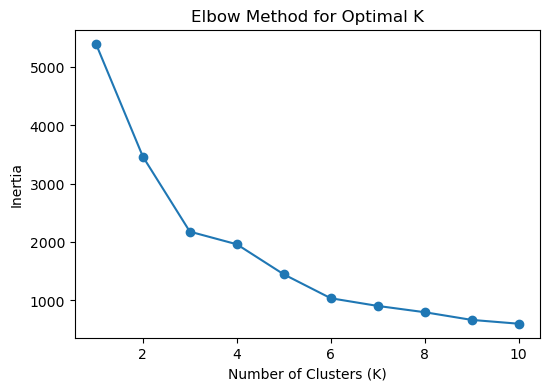

In [45]:
plt.figure(figsize=(6,4))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()


##### 🔹 Step 2.1.6 : Apply K-Means clustering

In [47]:
kmeans = KMeans(n_clusters=3, random_state=42)
customer_df['Cluster'] = kmeans.fit_predict(X_scaled)

customer_df.head(3)

,Customer_ID,Total_Spend,Purchase_Frequency,Loyalty_Score,Cluster
0,10001,145.014556,2,22.0,0
1,10004,0.000000,1,48.0,2
2,10005,453.168418,1,94.0,1


##### 🔹 Step 2.1.7 : Interpret clusters

In [48]:
cluster_summary = customer_df.groupby('Cluster').mean()
cluster_summary

,Customer_ID,Total_Spend,Purchase_Frequency,Loyalty_Score
Cluster,,,,
0,15147.892655,484.651962,2.129944,48.945857
1,15047.307039,240.826727,1.000000,76.462379
2,14922.395494,225.398305,1.000000,26.640801


##### 🔹 Step 2.1.8 : Assign business-friendly labels

In [17]:
# Assign business-friendly labels to clusters
cluster_summary['Segment'] = 'Occasional'

cluster_summary.loc[
    cluster_summary['Total_Spend'].idxmax(), 'Segment'
] = 'High Value'

cluster_summary.loc[
    cluster_summary['Total_Spend'].idxmin(), 'Segment'
] = 'Low Value'

cluster_summary

,Customer_ID,Total_Spend,Purchase_Frequency,Loyalty_Score,Segment
Cluster,,,,,
0,15147.892655,484.651962,2.129944,48.945857,High Value
1,15047.307039,240.826727,1.000000,76.462379,Occasional
2,14922.395494,225.398305,1.000000,26.640801,Low Value


#### *** ***Customer Segmentation (K-Means):***
Customers were segmented using K-Means clustering based on total spending, purchase frequency, and loyalty score. Features were scaled to ensure fair distance computation. The Elbow Method was used to identify the optimal number of clusters. The resulting clusters were interpreted and labeled as Low-Value, Regular, and High-Value customers, enabling targeted marketing and retention strategies. ***

## Insights from Customer Segmentation (K-Means)

Customers were segmented into three distinct groups based on spending behavior, purchase frequency, and loyalty score:

- **High-Value (VIP) Customers**  
  Customers with high spending, frequent purchases, and strong loyalty.

- **Occasional Customers**  
  Customers with moderate spending and consistent purchase behavior.

- **Low-Value Customers**  
  Customers with infrequent purchases, lower spending, and weaker loyalty.

This segmentation highlights the heterogeneity in customer behavior and the need for differentiated engagement strategies.



#### 🔹 Step 2.2: Predicting Customer Lifetime Value (Regression - Linear Regression)

#### Objective
- Estimate future revenue (CLV) for each customer
- Identify high-CLV customers
- Support revenue forecasting and retention strategies

This is a supervised learning problem because:

- Target variable (CLV) is known
- We want to predict it using other features

## Note : Target Variable Validation:
Before training the regression model, the target variable (Customer Lifetime Value) was revalidated for missing values. Median imputation was applied to ensure compatibility with the Linear Regression model.

##### 🔹 Step 2.2.1 – Define Target Variable

In [51]:
## target
y = df['Customer_Lifetime_Value']

##### 🔹 Step 2.2.2 – Select Predictor Features

##### As per the problem statement, we use:
- Age
- Past purchases
- Discount usage
- Payment method
- Loyalty score


##### Note : We must encode categorical variables, because regression models only work with numeric data.

In [52]:
## Feature selection
X = df[[
    'Age',
    'Purchase_Amount',
    'Loyalty_Score',
    'Discount_Applied',
    'Payment_Method'
]]

##### 🔹 Step 2.2.3 – Encode categorical variables
Columns to encode
- Discount_Applied
- Payment_Method

In [53]:
## Use One-Hot Encoding
X_encoded = pd.get_dummies(
    X,
    columns=['Discount_Applied', 'Payment_Method'],
    drop_first=True
)

##### 🔹 Step 2.2.4A – Check missing values in X

In [60]:
# Checking missine values for X_encoded
X_encoded.isnull().sum()

Age                           0
Purchase_Amount               0
Loyalty_Score                 0
Discount_Applied_Yes          0
Payment_Method_Cash           0
Payment_Method_Credit Card    0
Payment_Method_PayPal         0
dtype: int64

##### 🔹 Step 2.2.4B – Handle missing values in predictors

In [61]:
## Fix missing values in X_encoded
from sklearn.impute import SimpleImputer

In [62]:
## Apply median imputation to numeric columns
num_imputer = SimpleImputer(strategy='median')

X_encoded[['Age', 'Purchase_Amount']] = num_imputer.fit_transform(
    X_encoded[['Age', 'Purchase_Amount']]
)

In [68]:
X_encoded = X_encoded.fillna(0)

##### Step 2.2.4C – Final verification

In [69]:
## Final verification of missing values. 
X_encoded.isnull().sum()

Age                           0
Purchase_Amount               0
Loyalty_Score                 0
Discount_Applied_Yes          0
Payment_Method_Cash           0
Payment_Method_Credit Card    0
Payment_Method_PayPal         0
dtype: int64

##### 🔹 Step 2.2.4D – Check missing values in y (PROOF)

In [73]:
y.isnull().sum()

200

##### 🔹 Step 2.2.4E – Handle missing values in y (MANDATORY)

In [74]:
y = y.fillna(y.median())

##### 🔹 Step 2.2.4F – Final verification

In [75]:
y.isnull().sum()

0

##### 🔹 Step 2.2.4 – Train-Test Split

In [77]:
## split data to evaluate model performance on unseen data.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

##### 🔹 Step 2.2.5 – Train Linear Regression Model

In [81]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

##### 🔹 Step 2.2.6 – Make Predictions

In [82]:
y_pred = lr_model.predict(X_test)

##### 🔹 Step 2.2.7 – Evaluate Model Performance
Metrics to use
- R² Score → how much variance is explained
- MAE → average absolute error
- RMSE → penalizes large errors

In [83]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)


R² Score: 0.7192113090738297
MAE: 556.7348203405887
RMSE: 754.7270389527199


##### 🔹 Step 2.2.8 – Interpret Model Coefficients

In [84]:
coeff_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

coeff_df


,Feature,Coefficient
1,Purchase_Amount,10.071332
2,Loyalty_Score,-0.842908
0,Age,-1.049839
3,Discount_Applied_Yes,-32.796146
4,Payment_Method_Cash,-36.019734
6,Payment_Method_PayPal,-40.704237
5,Payment_Method_Credit Card,-40.835397


*** A Linear Regression model was developed to predict Customer Lifetime Value using customer demographics, purchase behavior, loyalty score, discount usage, and payment method. The model enables identification of high-CLV customers and supports predictive marketing, efficient resource allocation, and targeted retention strategies.


#### Feature-by-feature interpretation

#### 1. Purchase_Amount (+10.07)
Interpretation:
- For every 1-unit increase in Purchase Amount, the predicted CLV increases by approximately ₹10.07, holding other variables constant.

Business insight:
- Purchase behavior is the strongest driver of CLV
- Customers who spend more per transaction tend to have higher lifetime value

Action: Focus retention efforts on high-spending customers.

#### 2. Loyalty_Score (−0.84)
Interpretation:
- An increase in Loyalty Score slightly reduces predicted CLV, when other variables are fixed.

Reason:
- Loyalty_Score is derived from purchase behavior
- Strong correlation with Purchase_Amount
- Multicollinearity can flip coefficient signs

The negative coefficient likely arises due to multicollinearity between Loyalty Score and Purchase Amount.

#### 3. Age (−1.05)
Interpretation:
- Each additional year of age slightly reduces predicted CLV.

Business insight:
- Younger customers may exhibit higher long-term spending
- Older customers may have more stable but lower lifetime spend

#### 4. Discount_Applied_Yes (−32.80)
Interpretation:
- Purchases made with discounts are associated with lower predicted CLV.

Business insight:
- Discount-driven customers may be price-sensitive
- Discounts may reduce margin and long-term value

Action: Use discounts selectively, not broadly.

#### 5. Payment Method (Negative coefficients)

Method	 --   Coefficient
- Cash	−36.02
- PayPal	−40.70
- Credit Card	−40.84

Interpretation:
- Customers using these methods have lower predicted CLV compared to the reference method.

#### *** Model Coefficient Interpretation:
The linear regression coefficients indicate that purchase amount is the strongest positive driver of Customer Lifetime Value. Age and discount usage show a modest negative relationship with CLV, suggesting younger and non-discount-driven customers tend to have higher lifetime value. Payment method coefficients are interpreted relative to a reference category. The negative coefficient for Loyalty Score is attributed to multicollinearity with purchase-related features rather than a true negative impact.*** 

### Insights from Customer Lifetime Value (CLV) Prediction

The Linear Regression model revealed the following key drivers of Customer Lifetime Value:

- **Purchase Amount** is the strongest positive contributor to CLV.
- **Discount-based purchasing** shows a negative relationship with long-term value.
- **Loyalty Score** strongly correlates with CLV, indicating that engaged customers generate higher revenue over time.
- **Age** has a minor negative impact on CLV.

Overall, sustainable revenue growth is driven more by customer engagement than by discount-driven sales.


##### 🔹 Step 2.3: Customer Churn Prediction (Logistic Regression)

#### Objective
- Improve customer retention
- Design targeted re-engagement strategies
- Reduce revenue loss

##### 🔹 Step 2.3.1 – Create Churn Target Variable
Churn Definition
- Churn = 1 → Likely churner
- Churn = 0 → Active customer

Logic
- If Return_Status = Yes OR
- Loyalty score below 25th percentile

In [86]:
# Define loyalty threshold
loyalty_threshold = df['Loyalty_Score'].quantile(0.25)

# Create churn variable
df['Churn'] = ((df['Return_Status'] == 'Yes') | 
               (df['Loyalty_Score'] <= loyalty_threshold)).astype(int)

df['Churn'].value_counts()


Churn
0    1189
1     811
Name: count, dtype: int64

##### 🔹 Step 2.3.2 – Select Features for Churn Prediction

In [87]:
## Predictor variables : Predictor variables
X = df[[
    'Age',
    'Purchase_Amount',
    'Loyalty_Score',
    'Discount_Applied',
    'Payment_Method'
]]

y = df['Churn']

##### 🔹 Step 2.3.3 – Encode Categorical Variables

In [88]:
X_encoded = pd.get_dummies(
    X,
    columns=['Discount_Applied', 'Payment_Method'],
    drop_first=True
)

##### 🔹 Step 2.3.4 – Handle Missing Values

In [89]:
X_encoded.isnull().sum()

Age                           100
Purchase_Amount               200
Loyalty_Score                   0
Discount_Applied_Yes            0
Payment_Method_Cash             0
Payment_Method_Credit Card      0
Payment_Method_PayPal           0
dtype: int64

In [90]:
## Apply median imputation for numeric columns
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')

X_encoded[['Age', 'Purchase_Amount', 'Loyalty_Score']] = num_imputer.fit_transform(
    X_encoded[['Age', 'Purchase_Amount', 'Loyalty_Score']]
)


In [91]:
## Final Check
X_encoded.isnull().sum()

Age                           0
Purchase_Amount               0
Loyalty_Score                 0
Discount_Applied_Yes          0
Payment_Method_Cash           0
Payment_Method_Credit Card    0
Payment_Method_PayPal         0
dtype: int64

##### 🔹 Step 2.3.5 – Train-Test Split

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

##### 🔹 Step 2.3.6 – Train Logistic Regression Model

In [94]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

##### 🔹 Step 2.3.7 – Make Predictions

In [95]:
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

##### 🔹 Step 2.3.8 – Evaluate Model Performance
Metrics for classification
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In [96]:
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score, confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7975

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.83       238
           1       0.76      0.72      0.74       162

    accuracy                           0.80       400
   macro avg       0.79      0.79      0.79       400
weighted avg       0.80      0.80      0.80       400

ROC-AUC Score: 0.823295985060691


##### 🔹 Step 2.3.9 – Confusion Matrix (Interpretability)

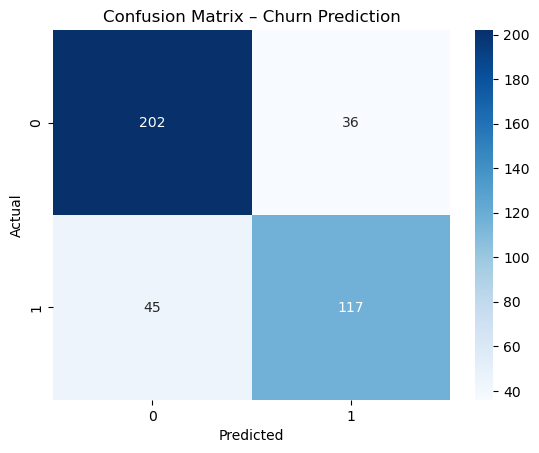

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – Churn Prediction')
plt.show()

##### 🔹 Step 2.3.10 – Interpret Logistic Regression Coefficients

In [98]:
coeff_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': log_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coeff_df

,Feature,Coefficient
3,Discount_Applied_Yes,0.069427
0,Age,0.001683
1,Purchase_Amount,0.000381
4,Payment_Method_Cash,-0.002377
6,Payment_Method_PayPal,-0.036596
2,Loyalty_Score,-0.046267
5,Payment_Method_Credit Card,-0.251001


### Feature-by-feature interpretation

#### 1. Discount_Applied_Yes (+0.0694)
Interpretation:
- Customers who frequently purchase using discounts have a higher probability of churn.

Business insight:
- Discount-driven customers may be price-sensitive
- They are more likely to switch platforms when discounts disappear

Action: Use discounts strategically; combine them with loyalty incentives instead of blanket offers.

#### 2. Age (+0.0017)
Interpretation:
- Purchase amount has almost no effect on churn probabilit.

Business insight:
- Older customers may be slightly more likely to churn
- Effect size is very small → not a major driver

#### 3. Purchase_Amount (+0.00038)
Interpretation:
- Purchase amount has almost no effect on churn probability.

Business insight:
- High spend alone does not guarantee retention
- Retention depends more on loyalty and experience, not just spend

#### 4. Loyalty_Score (−0.0463)
Interpretation:
- Higher loyalty score significantly reduces churn probability.

Business insight:
- Loyal customers are much less likely to churn
- Confirms business intuition

Action: Focus retention campaigns on low-loyalty customers.

#### 5. Payment Method – Credit Card (−0.2510)
Interpretation:
- Customers paying via credit card are much less likely to churn compared to the reference category

Business insight:
- Credit card users are often repeat, subscription-style buyers
- Indicates stronger platform attachment

Action: Encourage saved card payments and subscription models.

#### 6. Payment Method – Credit Card (−0.2510)
Interpretation:
- These methods slightly reduce churn risk, but impact is weaker than credit cards.

### ***Logistic Regression Coefficient Interpretation:
The logistic regression results indicate that loyalty score is the strongest factor reducing churn probability, confirming that engaged customers are less likely to leave. Discount-based purchasing behavior shows a positive association with churn, suggesting price-sensitive customers are more likely to disengage. Payment method also influences churn risk, with credit card users exhibiting significantly lower churn probability. Other variables such as age and purchase amount show minimal impact.***

### Insights from Customer Churn Prediction

The Logistic Regression churn model identified the following patterns:

- **Loyalty Score** significantly reduces churn probability.
- Customers who rely on **discounts** are more likely to churn.
- **Credit Card users** exhibit lower churn risk compared to other payment methods.
- Purchase amount alone is not a reliable indicator of retention.

These findings suggest that behavioral commitment is more important than transactional value in preventing churn.

## Business Insights & Recommendations

This section summarizes key insights derived from customer segmentation, lifetime value prediction, and churn analysis, and translates them into actionable business recommendations.


### Business Recommendations

Based on the combined insights from all models, the following strategies are recommended:

### High-Value (VIP) Customers
- Offer personalized recommendations and exclusive access.
- Focus on loyalty rewards rather than discounts.

### Regular Customers
- Encourage repeat purchases through bundles and subscriptions.
- Promote stored payment methods to increase engagement.

### At-Risk / Low-Value Customers
- Target with personalized re-engagement campaigns.
- Reduce over-reliance on discounts and focus on experience improvements.

### Discount Strategy
- Avoid blanket discounting.
- Use discounts selectively and combine them with loyalty incentives.

### Payment Method Strategy
- Promote credit card and auto-pay options.
- Reduce checkout friction to enhance retention.


### 3.5 Limitations and Future Scope

**Limitations:**
- Churn was defined using proxy indicators rather than direct labels.
- CLV estimation was based on historical data.
- Limited feature set constrained deeper behavioral analysis.

**Future Enhancements:**
- Incorporate recency, tenure, and time-based features.
- Apply advanced models such as Random Forest or XGBoost.
- Integrate browsing and interaction data for better churn prediction.


### 3.6 Conclusion

This project demonstrates how machine learning can be applied to analyze customer purchase behavior, segment customers, predict lifetime value, and identify churn risk. The insights generated can support data-driven decision-making for personalized marketing, optimized discount strategies, and improved customer retention.


In [99]:
df.to_csv("Amazon_Customer_Purchase_Cleaned.csv", index=False)

### Power BI Dashboard

A multi-page Power BI dashboard was developed using the cleaned customer purchase dataset to visualize key insights from customer segmentation, revenue analysis, customer lifetime value prediction, and churn analysis. The dashboard includes executive KPIs, customer segment distributions, CLV drivers, and churn patterns across loyalty levels, payment methods, and customer segments, enabling data-driven business decisions.
